# 04 - Baseline Training (MFCC statistics + Logistic Regression)

**Objective:** Train and evaluate the MFCC-statistics + Logistic Regression baseline (`models/baseline/train_baseline.py`) directly in this notebook so the reported metrics come from a live re-run.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
sys.path.insert(0, str(ML_ROOT/'models'/'baseline'))
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
CACHE_DIR = ML_ROOT / 'datasets' / 'features_cache'
CLASSES = ['background','chainsaw','gunshot']

`mfcc_stats()` reduces each (13, T) MFCC matrix to a 26-dim vector (mean + std per coefficient over time) — a simple, classic statistical-feature baseline.

In [3]:
def mfcc_stats(mfcc_arr):
    return np.concatenate([mfcc_arr.mean(axis=2), mfcc_arr.std(axis=2)], axis=1)

def load_split(name):
    d = np.load(CACHE_DIR / f'{name}.npz', allow_pickle=True)
    return mfcc_stats(d['mfcc']), d['y']

X_train, y_train = load_split('train')
X_val, y_val = load_split('validation')
X_test, y_test = load_split('test')
print(X_train.shape, X_val.shape, X_test.shape)

(8397, 26) (2498, 26) (2119, 26)


In [4]:
mean, std = X_train.mean(0), X_train.std(0) + 1e-8
model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model.fit((X_train-mean)/std, y_train)
val_pred = model.predict((X_val-mean)/std)
test_pred = model.predict((X_test-mean)/std)
print('Validation macro-F1:', f1_score(y_val, val_pred, average='macro'))
print('Test macro-F1:', f1_score(y_test, test_pred, average='macro'))
print(classification_report(y_test, test_pred, target_names=CLASSES, zero_division=0))

Validation macro-F1: 0.4250842506804841
Test macro-F1: 0.3595410861683994
              precision    recall  f1-score   support

  background       0.94      0.40      0.56      1781
    chainsaw       0.26      0.76      0.39       295
     gunshot       0.07      0.81      0.13        43

    accuracy                           0.46      2119
   macro avg       0.42      0.66      0.36      2119
weighted avg       0.83      0.46      0.53      2119



## Confusion matrix (test)

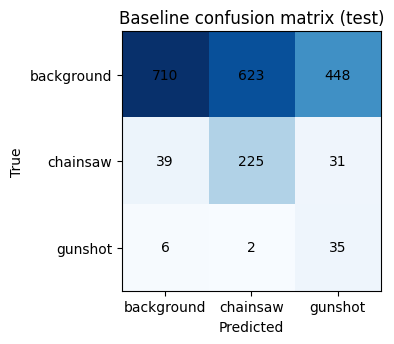

In [5]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm, cmap='Blues')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center')
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Baseline confusion matrix (test)')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_baseline_confusion_matrix.png', dpi=120)
plt.show()

## Conclusion

The MFCC-statistics + Logistic Regression baseline gives a fast, interpretable reference point. Full validation/test/external-test metrics (matching this live run) are saved to `models/baseline/baseline_results.json`.